In [1]:
import os
import warnings
warnings.filterwarnings("ignore", message=".*Ignoring cached namespace.*") # Stops annoying library version warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

/Users/lyn/miniforge3/envs/allensdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
output_dir = '/Users/lyn/Documents/UCSD Stuffs/DSC 180A/allensdk-data' # must be updated to a valid directory in your filesystem
DOWNLOAD_COMPLETE_DATASET = True

manifest_path = os.path.join(output_dir, "manifest.json")

cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

In [3]:
sessions = cache.get_session_table()

print('Total number of sessions: ' + str(len(sessions)))

sessions.head()

Total number of sessions: 58


,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


In [4]:
filtered_sessions = sessions[(sessions.session_type == 'brain_observatory_1.1') & \
                             (['VISl' in acronyms for acronyms in sessions.ecephys_structure_acronyms])]

filtered_sessions.head()

,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


In [5]:
session_id1 = 715093703
session1 = cache.get_session_data(session_id1)
session1.metadata

/Users/lyn/miniforge3/envs/allensdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/Users/lyn/miniforge3/envs/allensdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/Users/lyn/miniforge3/envs/all

{'specimen_name': 'Sst-IRES-Cre;Ai32-386129',
 'session_type': 'brain_observatory_1.1',
 'full_genotype': 'Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt',
 'sex': 'M',
 'age_in_days': 118.0,
 'rig_equipment_name': 'NP.1',
 'num_units': 884,
 'num_channels': 2219,
 'num_probes': 6,
 'num_stimulus_presentations': 70388,
 'session_start_time': datetime.datetime(2019, 1, 19, 0, 54, 18, tzinfo=tzoffset(None, -28800)),
 'ecephys_session_id': 715093703,
 'structure_acronyms': ['PO',
  'PoT',
  'LP',
  'DG',
  'CA1',
  'VISp',
  nan,
  'LGd',
  'CA3',
  'VISl',
  'VISrl',
  'grey',
  'VISpm',
  'VISam',
  'APN',
  'MB'],
 'stimulus_names': ['spontaneous',
  'gabors',
  'flashes',
  'drifting_gratings',
  'natural_movie_three',
  'natural_movie_one',
  'static_gratings',
  'natural_scenes']}

In [6]:
session_id2 = 750749662
session2 = cache.get_session_data(session_id2)
session2.metadata

{'specimen_name': 'C57BL/6J-412792',
 'session_type': 'brain_observatory_1.1',
 'full_genotype': 'wt/wt',
 'sex': 'M',
 'age_in_days': 92.0,
 'rig_equipment_name': 'NP.1',
 'num_units': 761,
 'num_channels': 2223,
 'num_probes': 6,
 'num_stimulus_presentations': 70390,
 'session_start_time': datetime.datetime(2018, 10, 26, 12, 58, 51, tzinfo=tzoffset(None, -25200)),
 'ecephys_session_id': 750749662,
 'structure_acronyms': ['VISpm',
  nan,
  'PO',
  'LD',
  'LP',
  'DG',
  'CA1',
  'LGd',
  'CA3',
  'VISrl',
  'Eth',
  'VISam',
  'VISp',
  'LGv',
  'IGL',
  'VISl',
  'VISal',
  'VPM',
  'TH',
  'CA2'],
 'stimulus_names': ['spontaneous',
  'gabors',
  'flashes',
  'drifting_gratings',
  'natural_movie_three',
  'natural_movie_one',
  'static_gratings',
  'natural_scenes']}

In [8]:
def get_units(session, stim="drifting_gratings", region="VISp"):
    stim_presentations = session.get_stimulus_table(stim)
    units = session.units[session.units["ecephys_structure_acronym"] == region]
    return stim_presentations, units

grating_presentations, v1_units = get_units(session1, region="VISp")
v1_units

,waveform_PT_ratio,waveform_amplitude,amplitude_cutoff,cluster_id,cumulative_drift,d_prime,firing_rate,isi_violations,isolation_distance,L_ratio,...,ecephys_structure_id,ecephys_structure_acronym,anterior_posterior_ccf_coordinate,dorsal_ventral_ccf_coordinate,left_right_ccf_coordinate,probe_description,location,probe_sampling_rate,probe_lfp_sampling_rate,probe_has_lfp_data
unit_id,,,,,,,,,,,,,,,,,,,,,
950930145,7.031742,102.55557,0.082525,410,202.02,4.343827,9.910598,0.011634,78.408045,2.632316e-03,...,385.0,VISp,8586.0,1465.0,8212.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930105,0.601677,79.86069,0.095761,408,145.08,5.052111,11.054619,0.011082,100.175018,6.946857e-03,...,385.0,VISp,8584.0,1477.0,8213.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930276,0.517356,82.90425,0.013349,415,101.96,3.670607,8.772900,0.025294,75.644463,2.471958e-03,...,385.0,VISp,8591.0,1441.0,8210.0,probeC,See electrode locations,29999.98547,1249.999395,True
950933698,0.476703,107.32878,0.000023,601,152.21,4.428315,1.277709,0.025923,47.931608,4.304661e-03,...,385.0,VISp,8589.0,1453.0,8211.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930237,0.567728,134.57301,0.001889,413,81.63,3.703712,3.280311,0.023598,50.545418,8.738876e-03,...,385.0,VISp,8589.0,1453.0,8211.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930215,0.359911,87.88728,0.013366,412,169.21,3.084614,6.514440,0.252301,58.611018,6.694053e-03,...,385.0,VISp,8589.0,1453.0,8211.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930358,0.503798,91.88673,0.064225,419,169.25,3.543693,10.520547,0.318126,70.577696,5.913075e-03,...,385.0,VISp,8596.0,1416.0,8207.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930340,0.480842,183.61161,0.000018,418,51.22,4.752755,1.674368,0.000000,55.450465,2.078934e-03,...,385.0,VISp,8596.0,1416.0,8207.0,probeC,See electrode locations,29999.98547,1249.999395,True
950930437,0.696938,107.46294,0.007229,425,200.18,5.016815,1.264046,0.211893,53.323600,1.602134e-03,...,385.0,VISp,8601.0,1392.0,8205.0,probeC,See electrode locations,29999.98547,1249.999395,True


In [12]:
def get_spikes(session, stim_presentations, units):
    spikes = session.presentationwise_spike_times(
        stimulus_presentation_ids=stim_presentations.index.values,
        unit_ids=units.index.values[:]
    )
    spikes = spikes.reset_index()
    return spikes

spikes = get_spikes(session1, grating_presentations, v1_units)
spikes

,spike_time,stimulus_presentation_id,unit_id,time_since_stimulus_presentation_onset
0,1574.778290,3798,950930358,0.003468
1,1574.780290,3798,950930407,0.005468
2,1574.781290,3798,950931581,0.006468
3,1574.782690,3798,950931254,0.007868
4,1574.783424,3798,950931315,0.008601
...,...,...,...,...
596746,5380.970047,49430,950933698,1.983919
596747,5380.972147,49430,950930407,1.986019
596748,5380.981414,49430,950931423,1.995286
596749,5380.981980,49430,950931853,1.995853


<Axes: >

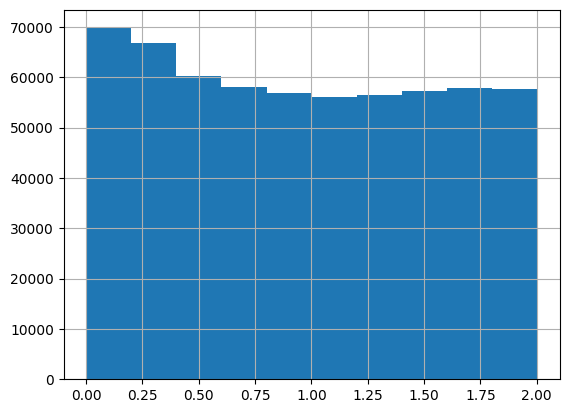

In [13]:
spikes['time_since_stimulus_presentation_onset'].hist()

In [14]:
def get_grating_angles(grating_presentations):
    grating_angles = grating_presentations["orientation"].reset_index()
    return grating_angles
grating_angles = get_grating_angles(grating_presentations)
grating_angles

,stimulus_presentation_id,orientation
0,3798,315.0
1,3799,90.0
2,3800,225.0
3,3801,90.0
4,3802,135.0
...,...,...
623,49426,135.0
624,49427,180.0
625,49428,0.0
626,49429,180.0


In [15]:
def clean_grating_spike_data(grating_spikes, grating_angles, window_size=0.2):
    grate_angle_spikes = spikes.merge(grating_angles, on="stimulus_presentation_id")
    fast_spikes_clean = grate_angle_spikes[(grate_angle_spikes["orientation"] != "null") & \
                                           (grate_angle_spikes["time_since_stimulus_presentation_onset"] <= window_size)]
    fast_spikes_clean = fast_spikes_clean.dropna()
    return fast_spikes_clean

s = 0.2
fast_spikes_clean = clean_grating_spike_data(spikes, grating_angles, window_size=s)
fast_spikes_clean

,spike_time,stimulus_presentation_id,unit_id,time_since_stimulus_presentation_onset,orientation
0,1574.778290,3798,950930358,0.003468,315.0
1,1574.780290,3798,950930407,0.005468,315.0
2,1574.781290,3798,950931581,0.006468,315.0
3,1574.782690,3798,950931254,0.007868,315.0
4,1574.783424,3798,950931315,0.008601,315.0
...,...,...,...,...,...
595834,5379.175713,49430,950930888,0.189585,270.0
595835,5379.178379,49430,950931254,0.192252,270.0
595836,5379.178579,49430,950931853,0.192452,270.0
595837,5379.179613,49430,950930215,0.193485,270.0


In [20]:
def summarize_grating_spike_rates(session, region="VISp", window_size=0.2):
    stim = "drifting_gratings" # Only get drifting_gratings data
    
    # Step 1: filter for spikes associated with drifting_gratings presentations
    grating_presentations, units = get_units(session, stim=stim, region=region)
    grating_spikes = get_spikes(session, grating_presentations, units)
    
    # Step 2: join with grating angle labels, removing any spikes that don't have an associated angle
    grating_angles = get_grating_angles(grating_presentations)
    fast_spikes_clean = clean_grating_spike_data(grating_spikes, grating_angles, window_size=0.2)
    
    # Step 3: compute rate per (angle, unit)
    firing_rates = (
        fast_spikes_clean
        .groupby(['stimulus_presentation_id', 'unit_id'])
        .size()
        .div(window_size)
        .rename('rate_hz')
        .reset_index()
    )
    firing_rates = firing_rates.merge(grating_angles, on="stimulus_presentation_id")
    
    # Step 4: calculate mean and 95% CIs for each angle
    summary_stats = (
        firing_rates
        .groupby('orientation')['rate_hz']
        .agg(['mean', 'std', 'count'])
        .sort_values(by='orientation')
        .reset_index()
    )
    summary_stats['ci95'] = 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])

    return summary_stats
    
summarize_grating_spike_rates(session1, region="VISp")

,orientation,mean,std,count,ci95
0,0.0,19.541118,21.125023,2201,0.882558
1,45.0,19.128361,20.708157,2306,0.845216
2,90.0,19.572569,20.646404,2129,0.877026
3,135.0,16.848393,19.328808,2302,0.789602
4,180.0,19.228942,21.197905,2315,0.863522
5,225.0,18.740209,19.966536,2298,0.816364
6,270.0,19.006522,20.147401,2300,0.823401
7,315.0,17.914013,19.743009,2198,0.825383


In [28]:
def visualize_grating_spike_rates(session, region="VISp", window_size=0.2):
    summary = summarize_grating_spike_rates(session1, region=region, window_size=window_size)
    
    # plot avg firing rates against grating angle
    plt.plot(summary['orientation'], summary['mean'], 'o-')
    plt.errorbar(
        summary['orientation'],
        summary['mean'],
        yerr=summary['ci95'],
        fmt='o-',
        color='navy',
        ecolor='crimson',
        capsize=4,
        label='mean ± 95% CI'
    )
    
    plt.title(f'{region} Firing Rates for Drifting Gratings (Specimen {session.specimen_name})')
    plt.xlabel('Grating orientation (deg)')
    degree_labels = np.arange(0, 360, 45)
    plt.xticks(
        ticks=degree_labels, # 0, 45, 90, ..., 315
        labels=[f'{d}°' for d in degree_labels]
    )
    plt.ylabel('Average firing rate (Hz)')
    plt.show()

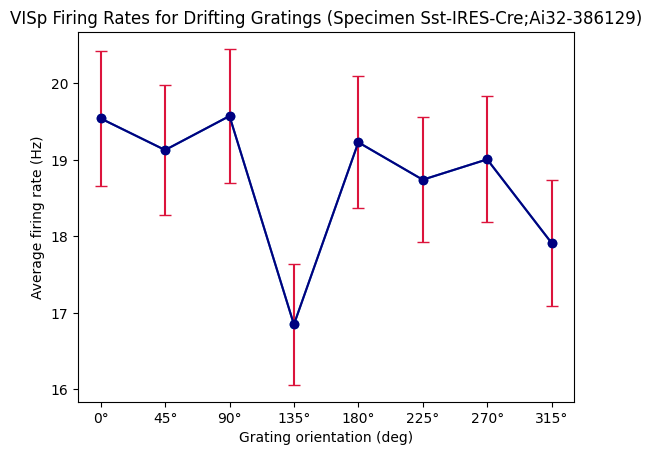

In [29]:
visualize_grating_spike_rates(session1, region="VISp")

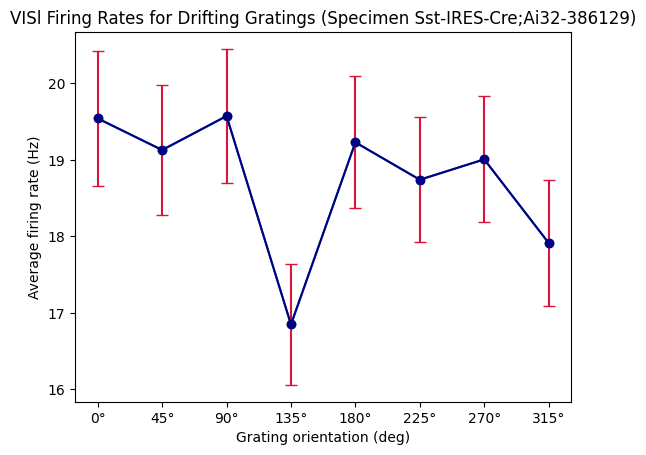

In [30]:
visualize_grating_spike_rates(session1, region="VISl")

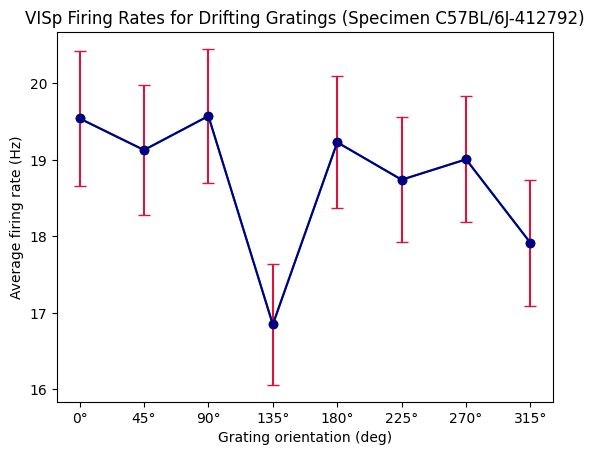

In [31]:
visualize_grating_spike_rates(session2, region="VISp")

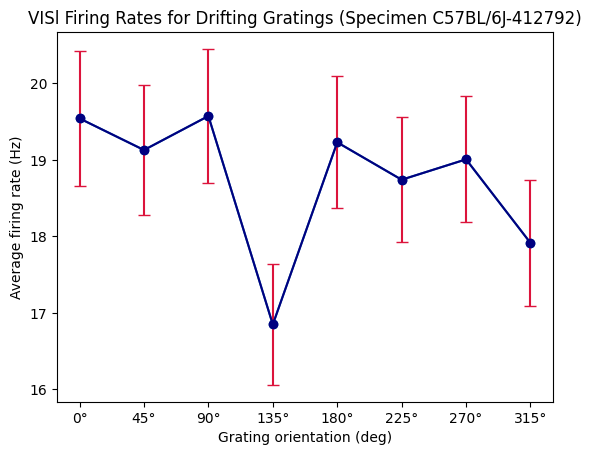

In [32]:
visualize_grating_spike_rates(session2, region="VISl")